# LRG triangulation with parameter r

This notebook loads one LRG rosette from `data/edr/old_data`, computes the parameter `r` from the combined data and random Delaunay network, selects a subset of the rosette, projects it to 2D, and plots the triangulation with separate markers for data and random points.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from astropy.table import Table
from matplotlib.patches import ConnectionPatch, Rectangle
from scipy.spatial import Delaunay

plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams["axes.linewidth"] = 1.2


In [2]:
def load_rosette_table(base_dir, tracer, rosette, kind):
    path = Path(base_dir) / f"{tracer}_{rosette}_clustering_{kind}.ecsv"
    table = Table.read(path, format="ascii.ecsv")
    df = table[["TARGETID", "RA", "DEC", "Z", "x", "y", "z"]].to_pandas()
    df["type"] = "data" if kind == "data" else "rand"
    return df


def compute_parameter_r(df):
    coords = df[["x", "y", "z"]].to_numpy()
    tri = Delaunay(coords)

    graph = nx.Graph()
    graph.add_nodes_from(range(len(df)))

    for simplex in tri.simplices:
        for i in range(3):
            for j in range(i + 1, 4):
                graph.add_edge(int(simplex[i]), int(simplex[j]))

    types = df["type"].to_numpy()
    n_data = np.zeros(len(df), dtype=int)
    n_rand = np.zeros(len(df), dtype=int)

    for node in graph.nodes:
        for neighbor in graph.neighbors(node):
            if types[neighbor] == "data":
                n_data[node] += 1
            else:
                n_rand[node] += 1

    denom = n_data + n_rand
    r = np.where(denom != 0, (n_data - n_rand) / denom, np.nan)

    result = df.copy()
    result["N_data"] = n_data
    result["N_random"] = n_rand
    result["r"] = r
    return result


def add_principal_components(df):
    coords = df[["x", "y", "z"]].to_numpy(dtype=float)
    centered = coords - coords.mean(axis=0, keepdims=True)
    cov = np.cov(centered, rowvar=False)
    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    basis = evecs[:, order]
    projected = centered @ basis

    result = df.copy()
    result["pc1"] = projected[:, 0] - projected[:, 0].min()
    result["pc2"] = projected[:, 1] - projected[:, 1].min()
    result["pc3"] = projected[:, 2] - projected[:, 2].min()
    return result


def select_pc_subset(df, pc1_range=(0.0, 200.0), pc2_range=None):
    x0, x1 = pc1_range
    if pc2_range is None:
        y0 = df["pc2"].min()
        y1 = df["pc2"].max()
    else:
        y0, y1 = pc2_range

    subset = df[
        df["pc1"].between(x0, x1)
        & df["pc2"].between(y0, y1)
    ].copy()

    if subset.empty:
        raise ValueError("The selected PC1-PC2 window produced an empty subset.")
    return subset


def plot_triangulation_with_r(
    df,
    x_col,
    y_col,
    x_label,
    y_label,
    title,
    save_path=None,
    inset_df=None,
    show_colorbar=True,
    use_r=True,
    colorbar_position="right",
    xlim=None,
    point_size=16,
    point_lw=0.2,
    inset_point_size=18,
    inset_point_lw=0.25,
    colorbar_pad=0.01,
    colorbar_fraction=0.042,
    ylim=None,
    legend_fontsize=14,
    tick_labelsize=14,
    colorbar_ticksize=12,
    colorbar_labelsize=22,
    axis_labelsize=18,
    title_fontsize=20,
):
    def draw_triangulation(ax_obj, plot_df, point_size, point_lw):
        tri = Delaunay(np.column_stack([plot_df[x_col].to_numpy(), plot_df[y_col].to_numpy()]))
        x_vals = plot_df[x_col].to_numpy()
        y_vals = plot_df[y_col].to_numpy()

        for simplex in tri.simplices:
            cycle = [simplex[0], simplex[1], simplex[2], simplex[0]]
            ax_obj.plot(x_vals[cycle], y_vals[cycle], color="0.70", linewidth=0.30, alpha=0.7, zorder=1)

        data_mask = plot_df["type"] == "data"
        rand_mask = plot_df["type"] == "rand"

        if use_r:
            scatter = ax_obj.scatter(
                plot_df.loc[data_mask, x_col],
                plot_df.loc[data_mask, y_col],
                c=plot_df.loc[data_mask, "r"],
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
                s=point_size,
                marker="o",
                edgecolors="black",
                linewidths=point_lw,
                zorder=3,
            )

            ax_obj.scatter(
                plot_df.loc[rand_mask, x_col],
                plot_df.loc[rand_mask, y_col],
                c=plot_df.loc[rand_mask, "r"],
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
                s=point_size,
                marker="^",
                edgecolors="black",
                linewidths=point_lw,
                zorder=6,
            )
        else:
            scatter = None
            ax_obj.scatter(
                plot_df.loc[data_mask, x_col],
                plot_df.loc[data_mask, y_col],
                color="tab:blue",
                s=point_size,
                marker="o",
                edgecolors="black",
                linewidths=point_lw,
                zorder=3,
            )
            ax_obj.scatter(
                plot_df.loc[rand_mask, x_col],
                plot_df.loc[rand_mask, y_col],
                color="tab:orange",
                s=point_size,
                marker="^",
                edgecolors="black",
                linewidths=point_lw,
                zorder=4,
            )
        return scatter

    fig, ax = plt.subplots(figsize=(14, 10))
    if inset_df is not None:
        fig.subplots_adjust(right=0.66)

    scatter_data = draw_triangulation(ax, df, point_size=point_size, point_lw=point_lw)

    if show_colorbar and use_r and scatter_data is not None:
        if colorbar_position == "bottom":
            cbar = fig.colorbar(scatter_data, ax=ax, orientation="horizontal", pad=colorbar_pad, fraction=colorbar_fraction)
        else:
            cbar = fig.colorbar(scatter_data, ax=ax, pad=colorbar_pad)
        cbar.set_label(r"$r$", fontsize=colorbar_labelsize)
        cbar.ax.tick_params(labelsize=colorbar_ticksize)

    data_handle = plt.Line2D(
        [], [], linestyle="None", marker="o", markersize=8,
        markerfacecolor="white", markeredgecolor="black", label="Data"
    )
    rand_handle = plt.Line2D(
        [], [], linestyle="None", marker="^", markersize=8,
        markerfacecolor="white", markeredgecolor="black", label="Random"
    )

    ax.set_xlabel(x_label, fontsize=axis_labelsize)
    ax.set_ylabel(y_label, fontsize=axis_labelsize)
    ax.tick_params(axis="both", labelsize=tick_labelsize)
    ax.set_aspect("equal", adjustable="box")
    if xlim is not None:
        ax.set_xlim(*xlim)  
    if ylim is not None:
        ax.set_ylim(*ylim)
    #ax.grid(False, linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_title(title, fontsize=title_fontsize)
    legend = ax.legend(handles=[data_handle, rand_handle], loc="upper left", fontsize=legend_fontsize, frameon=True)
    legend.get_frame().set_facecolor(ax.get_facecolor())
    legend.get_frame().set_alpha(0.8)
    legend.get_frame().set_edgecolor((0.0, 0.0, 0.0, 0.8))
    legend.get_frame().set_linewidth(1.0)
    legend.set_zorder(1000)

    if inset_df is not None:
        x0 = inset_df[x_col].min()
        x1 = inset_df[x_col].max()
        y0 = inset_df[y_col].min()
        y1 = inset_df[y_col].max()

        zoom_box = Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            edgecolor="0.35",
            linestyle="--",
            linewidth=1.2,
            zorder=5,
        )
        ax.add_patch(zoom_box)

        axins = fig.add_axes([0.65, 0.32, 0.30, 0.42])
        draw_triangulation(axins, inset_df, point_size=inset_point_size, point_lw=inset_point_lw)
        axins.set_xlim(x0, x1)
        axins.set_ylim(y0, y1)
        axins.set_aspect("equal", adjustable="box")
        #axins.grid(False, linestyle="--", linewidth=0.4, alpha=0.35)
        axins.tick_params(axis="both", labelsize=10)
        axins.set_title("Zoom", fontsize=12)
        axins.set_xlabel(x_label, fontsize=10)
        axins.set_ylabel(y_label, fontsize=10)

        line_top = ConnectionPatch(
            xyA=(x1, y1),
            coordsA=ax.transData,
            xyB=(0.0, 1.0),
            coordsB=axins.transAxes,
            axesA=ax,
            axesB=axins,
            color="0.5",
            linestyle="--",
            linewidth=1.0,
        )
        line_bottom = ConnectionPatch(
            xyA=(x1, y0),
            coordsA=ax.transData,
            xyB=(0.0, 0.0),
            coordsB=axins.transAxes,
            axesA=ax,
            axesB=axins,
            color="0.5",
            linestyle="--",
            linewidth=1.0,
        )
        fig.add_artist(line_top)
        fig.add_artist(line_bottom)
    else:
        plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig, ax


def plot_3d_with_r(df, x_col, y_col, z_col, x_label, y_label, z_label, title, save_path=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")
    tri = Delaunay(np.column_stack([df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy()]))

    edges = set()
    for simplex in tri.simplices:
        for i in range(4):
            for j in range(i + 1, 4):
                edge = tuple(sorted((int(simplex[i]), int(simplex[j]))))
                edges.add(edge)

    x_vals = df[x_col].to_numpy()
    y_vals = df[y_col].to_numpy()
    z_vals = df[z_col].to_numpy()
    for i, j in edges:
        ax.plot(
            [x_vals[i], x_vals[j]],
            [y_vals[i], y_vals[j]],
            [z_vals[i], z_vals[j]],
            color="0.72",
            linewidth=0.25,
            alpha=0.35,
            zorder=1,
        )

    data_mask = df["type"] == "data"
    rand_mask = df["type"] == "rand"

    scatter_data = ax.scatter(
        df.loc[data_mask, x_col],
        df.loc[data_mask, y_col],
        df.loc[data_mask, z_col],
        c=df.loc[data_mask, "r"],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        s=18,
        marker="o",
        edgecolors="black",
        linewidths=0.2,
        label="Data",
        depthshade=False,
        zorder=3,
    )

    ax.scatter(
        df.loc[rand_mask, x_col],
        df.loc[rand_mask, y_col],
        df.loc[rand_mask, z_col],
        c=df.loc[rand_mask, "r"],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        s=18,
        marker="^",
        edgecolors="black",
        linewidths=0.2,
        label="Random",
        depthshade=False,
        zorder=6,
    )

    cbar = fig.colorbar(scatter_data, ax=ax, pad=0.05, shrink=0.8)
    cbar.set_label(r"$r$", fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    ax.set_xlabel(x_label, fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_zlabel(z_label, fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_title(title, fontsize=title_fontsize)
    legend = ax.legend(loc="upper left", fontsize=14, frameon=True)
    legend.get_frame().set_facecolor(ax.get_facecolor())
    legend.get_frame().set_alpha(1.0)
    legend.get_frame().set_edgecolor((0.0, 0.0, 0.0, 0.5))
    legend.get_frame().set_linewidth(1.0)
    legend.set_zorder(1000)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    return fig, ax


In [3]:
base_dir = "/Users/soguevaram/Desktop/Research/DESI/data/edr/old_data"
tracer = "LRG"
rosette = 0

data_df = load_rosette_table(base_dir, tracer, rosette, "data")
rand_df = load_rosette_table(base_dir, tracer, rosette, "rand")

rosette_df = pd.concat([data_df, rand_df], ignore_index=True)
rosette_df = compute_parameter_r(rosette_df)
rosette_df = add_principal_components(rosette_df)

subset_reduced = select_pc_subset(
    rosette_df,
    pc1_range=(1500, 2000),
    pc2_range=None,
)

subset_reduced[["type", "r", "RA", "DEC", "pc1", "pc2"]].head()


,type,r,RA,DEC,pc1,pc2
3,data,-0.500000,148.454082,2.501206,1743.523513,148.043257
15,data,0.142857,149.284606,2.882460,1583.208176,153.576112
18,data,0.666667,149.351307,2.270288,1665.168708,120.308058
22,data,-0.111111,149.963009,3.015056,1523.524748,149.467769
24,data,0.066667,150.790860,0.971047,1605.808239,28.047317


Figure saved to: /Users/soguevaram/Desktop/Research/DESI/plots/plot_astra.png


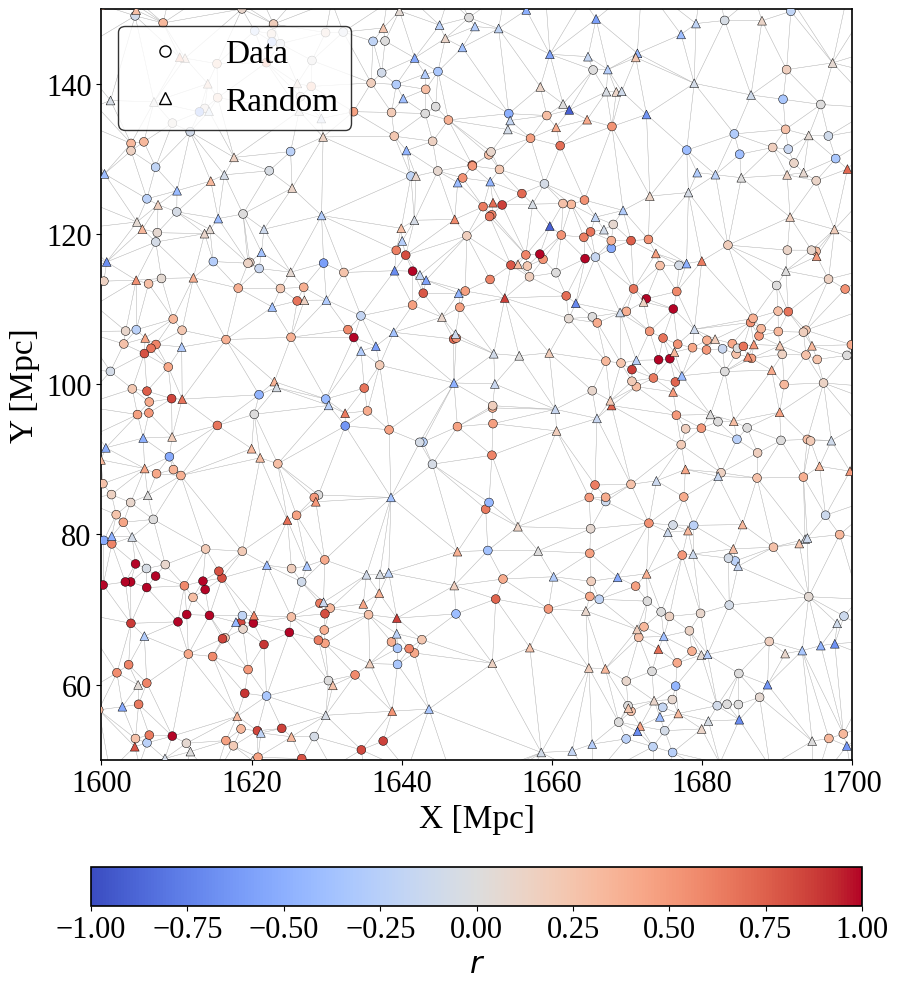

In [4]:
output_path_subset = Path("/Users/soguevaram/Desktop/Research/DESI/plots") / f"plot_astra.png"

fig_subset, ax_subset = plot_triangulation_with_r(
    subset_reduced,
    x_col="pc1",
    y_col="pc2",
    x_label="X [Mpc]",
    y_label="Y [Mpc]",
    title=None,
    save_path=output_path_subset,
    colorbar_position="bottom",
    xlim=(1600,1700),
    ylim=(50,150),
    point_size=40,
    point_lw=0.35,
    colorbar_pad=0.12,
    colorbar_fraction=0.043,
    legend_fontsize=24,
    tick_labelsize=22,
    colorbar_ticksize=22,
    axis_labelsize=24
    )